In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt  # Import matplotlib for plotting
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter
from sklearn.cluster import KMeans
from tqdm import tqdm
from tkinter import Tk
from tkinter.filedialog import askdirectory
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


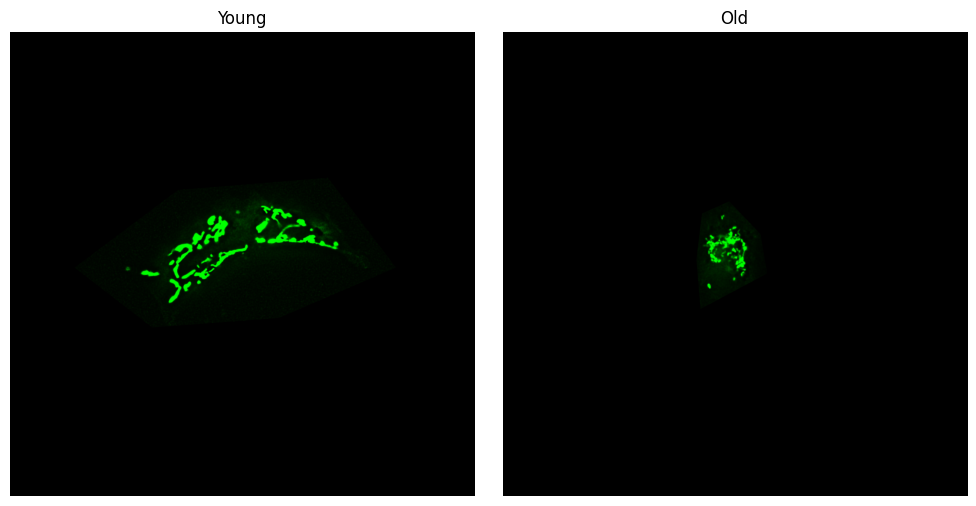

In [6]:
img_paths = [
    '/content/drive/MyDrive/Images/nuclei/training_set9/newest/aged/1002-2.tif',
    '/content/drive/MyDrive/Images/nuclei/training_set9/newest/young/1-1.tif'
    ]

plt.figure(figsize=(10, 5))

titles = ['Young', 'Old']

for i, path in enumerate(img_paths):
    img = plt.imread(path)
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(titles[i])

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Index  0    Filename: /content/drive/MyDrive/AI_ML/images3/97.tif
Index  1    Filename: /content/drive/MyDrive/AI_ML/images3/83.tif
Index  2    Filename: /content/drive/MyDrive/AI_ML/images3/84.tif
Index  3    Filename: /content/drive/MyDrive/AI_ML/images3/89.tif
Index  4    Filename: /content/drive/MyDrive/AI_ML/images3/102.tif
Index  5    Filename: /content/drive/MyDrive/AI_ML/images3/69.tif
Index  6    Filename: /content/drive/MyDrive/AI_ML/images3/99.tif
Index  7    Filename: /content/drive/MyDrive/AI_ML/images3/64.tif
Index  8    Filename: /content/drive/MyDrive/AI_ML/images3/87.tif
Index  9    Filename: /content/drive/MyDrive/AI_ML/images3/90.tif
Index  10    Filename: /content/drive/MyDrive/AI_ML/images3/100.tif
Index  11    Filename: /content/drive/MyDrive/AI_ML/images3/75.tif
Index  12    Filename: /content/drive/MyDrive/AI_ML/images3/73.tif
Index  1

  0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
 50%|█████     | 1/2 [00:03<00:03,  3.79s/it]



Run 1
[1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1
 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0 0 1]

Cluster 0 corresponds to the smaller group (22 images):
Image 6: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/99.tif
Image 21: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/93.tif
Image 26: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/76.tif
Image 33: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/98.tif
Image 38: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/88.tif
Image 39: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/65.tif
Image 41: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/58.tif
Image 49: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/50.tif
Image 51: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/52.tif
Image 57: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/41.tif
Image 59: Cluster 0  FN /content/drive/MyDrive/A

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
100%|██████████| 2/2 [00:07<00:00,  3.65s/it]



Run 2
[1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 1]

Cluster 0 corresponds to the smaller group (14 images):
Image 6: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/99.tif
Image 26: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/76.tif
Image 33: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/98.tif
Image 41: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/58.tif
Image 51: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/52.tif
Image 59: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/38.tif
Image 61: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/39.tif
Image 74: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/31.tif
Image 83: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/23.tif
Image 89: Cluster 0  FN /content/drive/MyDrive/AI_ML/images3/14.tif
Image 91: Cluster 0  FN /content/drive/MyDrive/A

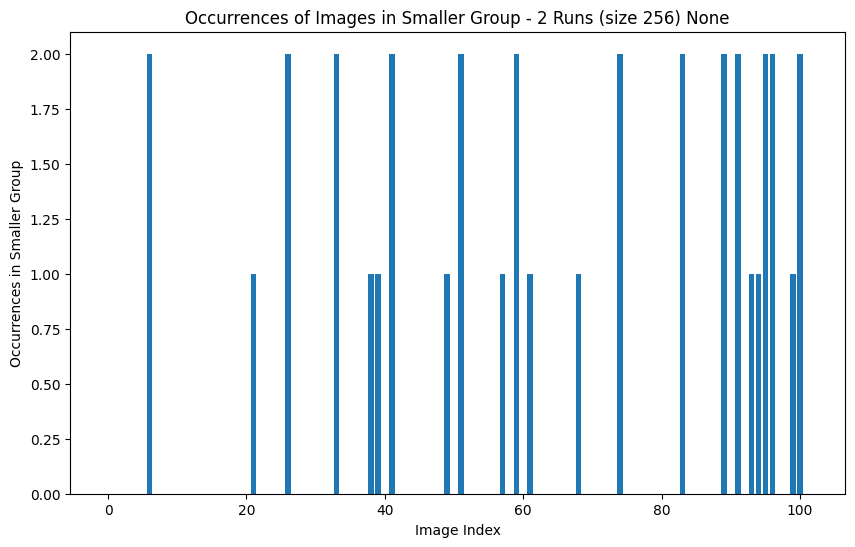

In [ ]:
def load_data_array(images, size=512):
  # Resize images
  for index, filename in enumerate(images):
    print(f'Index  {index}    Filename: {filename}')

  if (size != 'NONE'):
    data_array = np.array([np.array(Image.open(filename).resize((size, size))) for filename in images])
  else:
    data_array = np.array([np.array(Image.open(filename)) for filename in images])

  data_array = data_array / 255.0  # Normalize pixel values

  # Enhance brightness
  enhanced_images = []
  for img in data_array:
    enhancer = ImageEnhance.Brightness(Image.fromarray((img * 255).astype(np.uint8)))
    enhanced_img = enhancer.enhance(1.1)  # Adjust brightness factor (e.g., 1.2)
    enhanced_images.append(np.array(enhanced_img) / 255.0)

  # Apply sharpening
  sharpened_images = []
  for img in enhanced_images:
    sharpened_img = Image.fromarray((img * 255).astype(np.uint8)).filter(ImageFilter.SHARPEN)
    sharpened_images.append(np.array(sharpened_img) / 255.0)
  return np.array(sharpened_images).reshape(len(images), -1)  # Flatten images

def run_clustering(data, num_clusters=2, seed=None):
  kmeans = KMeans(n_clusters=num_clusters, random_state=seed)
  kmeans.fit(data)
  return kmeans.predict(data)

  # colors = ['red', 'green']
  # centroids_x = data[:, 0]
  # centroids_y = data[:, 1]
  # ax = sns.scatterplot(centroids_x, centroids_y, hue=kmeans.labels_, palette=colors, alpha=0.5, s=7)
  # ax = sns.scatterplot(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], hue=range(num_clusters), palette=colors, s=20, ec='black', legend=False, ax=ax)
  # plt.show()

  # plt.scatter(data[:, 0], data[:, 1], c=None, s=50, cmap='viridis')

  # centers = kmeans.cluster_centers_
  # print(centers[0].reshape(1024,1024,3))
  # plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

  # return kmeans.predict(data)

# NOT USED YET:
# Generate a feature stack (pixel values, blurred, and edges)
from skimage.io import imread
from skimage import filters
from sklearn.ensemble import RandomForestClassifier
def generate_feature_stack(image):
    blurred = filters.gaussian(image, sigma=2)
    edges = filters.sobel(blurred)
    feature_stack = [image.ravel(), blurred.ravel(), edges.ravel()]
    return np.asarray(feature_stack)


def main(image_path='CHOOSE',
         num_clusters=2,
         num_runs=4,
         size=512,
         seed=None):
  if image_path == 'CHOOSE':
    image_path = f'{askdirectory(title="Select a folder...")}/*.*'
  image_path = image_path  # Update with your actual image path
  image_list = glob.glob(f'{image_path}')
  data = load_data_array(image_list, size)

  # Create 1D array with all zeros
  small_cluster_count = np.zeros((len(image_list),))

  for run_num in tqdm(range(num_runs)):
    cluster_labels = run_clustering(data=data, num_clusters=num_clusters, seed=seed)
    print(f'\n\nRun {run_num+1}\n{cluster_labels}')

    # Count the occurrences of each cluster label
    label_counts = np.bincount(cluster_labels)

    # Determine the smaller group (assuming it's the one with fewer images)
    smaller_group_label = np.argmin(label_counts)

    print(f'''
Cluster {smaller_group_label} corresponds to the \
smaller group ({min(np.bincount(cluster_labels))} images):''')
    # Print the smaller group images
    for index, label in enumerate(cluster_labels):
      if label == smaller_group_label:
        print(f'Image {index}: Cluster {label}  FN {image_list[index]}')
        # update small_cluster_count at that position
        small_cluster_count[index] +=1

  # Create a bar graph
  plt.figure(figsize=(10, 6))
  plt.bar(range(len(small_cluster_count)), small_cluster_count)
  plt.xlabel('Image Index')
  plt.ylabel('Occurrences in Smaller Group')
  plt.title(f'Occurrences of Images in Smaller Group')
  plt.show()
  return small_cluster_count

if __name__ == '__main__':
  # Mount Google Drive or Comment out
  from google.colab import drive
  drive.mount('/content/drive')
  #
  # Check image path points to appropriate folder and files
  # Set the desired number of clusters (2), Resize size
  # and number of runs
  #
  image_path = '/content/drive/MyDrive/AI_ML/images3/*.tif'  # 'CHOOSE' or 'c:/content/images3/*.tif'  # or '/content/drive/MyDrive/AI_ML/images3'
  seed=None   # or None 42(2) 43(1) 45(10)
  num_clusters = 2
  size=256  # or 'NONE' for no resize
  num_runs = 2

  main(image_path=image_path,
       num_clusters=num_clusters,
       num_runs=num_runs,
       size=size,
       seed=seed)
